# Healthcare Referral Network Analysis

This notebook processes Medicare physician referral network data through a 6-step pipeline:
1. Extract DocGraph data from .txt files
2. Get NPI zip codes from NPI info
3. Join zip codes with DocGraph data
4. Create NetworkX graph from referral network data
5. Compute referral volume by zip code
6. Visualize a subset of the graph

## Cell 1: Imports

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from tqdm import tqdm
import time
from joblib import Parallel, delayed
import seaborn as sns
import statsmodels.formula.api as smf

## Step 1: Extract DocGraph Data

Extract and combine all DocGraph .txt files into a single DataFrame.

In [9]:
def extract_docgraph_data(data_dir=None, output_path=None, max_rows=None):
    """
    Extract and combine all DocGraph .txt files into a single CSV.
    
    Args:
        data_dir: Directory containing .txt data files. Defaults to "data/docgraph-data"
        output_path: Path for output CSV. Defaults to "data/docgraph-data/docgraph_combined.csv"
        max_rows: Maximum number of rows to process. Defaults to None (process all rows).
    
    Returns:
        pandas.DataFrame: Combined dataframe with all extracted data (only NPI_1, NPI_2, Pair_Count)
    """
    if data_dir is None:
        data_dir = os.path.join("data", "docgraph-data")
    
    # if output_path is None:
    #     output_path = os.path.join(data_dir, "docgraph_combined.csv")
    
    # List all .txt files in the folder except README.txt (case-insensitive)
    files = [f for f in os.listdir(data_dir) if f.endswith(".txt") and f.lower() != "readme.txt"]
    
    # Prepare an empty list to store DataFrames
    dfs = []
    total_rows_processed = 0
    
    if max_rows is not None:
        print(f"⚠️  Processing limited to first {max_rows:,} rows for testing")
    else:
        print("Processing all rows")
    
    # Loop through all files and read each one
    for filename in files:
        if max_rows is not None and total_rows_processed >= max_rows:
            print(f"\n⚠️  Reached limit of {max_rows:,} rows. Stopping processing.")
            break
            
        file_path = os.path.join(data_dir, filename)
        print(f"Loading {filename}...")
        
        # Read file in chunks to show progress
        chunk_list = []
        chunk_size = 10000  # Read 10k rows at a time
        
        # First, get total number of lines for progress bar
        with open(file_path, 'r') as f:
            total_lines = sum(1 for _ in f)
        
        # Read in chunks with progress bar - only load columns we need
        chunk_reader = pd.read_csv(
            file_path,
            header=None,
            names=["NPI_1", "NPI_2", "Pair_Count", "Unique_Beneficiaries", "Same_Day_Count"],
            usecols=[0, 1, 2],  # Only read NPI_1, NPI_2, Pair_Count
            dtype=str,
            chunksize=chunk_size
        )
        
        rows_read = 0
        if max_rows is not None:
            remaining_rows = max_rows - total_rows_processed
            pbar = tqdm(total=min(total_lines, remaining_rows), desc=f"Reading {filename}", unit="rows")
        else:
            pbar = tqdm(total=total_lines, desc=f"Reading {filename}", unit="rows")
        
        for chunk in chunk_reader:
            # Check if we've reached the limit
            if max_rows is not None and total_rows_processed >= max_rows:
                break
            
            # Trim chunk if it would exceed the limit
            if max_rows is not None:
                rows_needed = max_rows - total_rows_processed
                if len(chunk) > rows_needed:
                    chunk = chunk.head(rows_needed)
            
            # Clean whitespace
            chunk = chunk.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
            
            # Convert Pair_Count to int
            chunk["Pair_Count"] = chunk["Pair_Count"].astype(int)
            
            chunk_list.append(chunk)
            rows_read += len(chunk)
            total_rows_processed += len(chunk)
            pbar.update(len(chunk))
            
            if max_rows is not None and total_rows_processed >= max_rows:
                break
        
        pbar.close()
        
        # Combine chunks into single DataFrame
        if chunk_list:
            df = pd.concat(chunk_list, ignore_index=True)
            print(f"  Completed: {rows_read:,} rows read from {filename}")
            dfs.append(df)
        
        if max_rows is not None and total_rows_processed >= max_rows:
            break
    
    # Combine all files into one DataFrame
    combined_df = pd.concat(dfs, ignore_index=True)
    
    # Write combined output to CSV in the same directory
    if output_path is not None:
        combined_df.to_csv(output_path, index=False)
    
    # Preview the result
    print("\n✅ Combined Data Loaded Successfully!")
    if max_rows is not None:
        print(f"Total rows: {len(combined_df):,} (limited to {max_rows:,} for testing)")
    else:
        print(f"Total rows: {len(combined_df):,}")
    print(f"Columns: {list(combined_df.columns)} (only loading used columns to save memory)")
    print(combined_df.head())
    print(f"\n💾 Saved combined CSV to {output_path}")
    
    return combined_df

# Run Step 1
print("="*80)
print("Step 1: Extracting DocGraph Data")
print("="*80)
docgraph_df = extract_docgraph_data()

Step 1: Extracting DocGraph Data
Processing all rows
Loading physician-shared-patient-patterns-2015-days30.txt...


Reading physician-shared-patient-patterns-2015-days30.txt: 100%|██████████| 34856901/34856901 [00:16<00:00, 2123695.03rows/s]


  Completed: 34,856,901 rows read from physician-shared-patient-patterns-2015-days30.txt

✅ Combined Data Loaded Successfully!
Total rows: 34,856,901
Columns: ['NPI_1', 'NPI_2', 'Pair_Count'] (only loading used columns to save memory)
        NPI_1       NPI_2  Pair_Count
0  1000026017  1598773715          56
1  1000310429  1144645573          68
2  1003000126  1003951625         147
3  1003000126  1003975400          38
4  1003000126  1013051119          30

💾 Saved combined CSV to None


In [10]:
print(f"Memory: {docgraph_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Memory: 4188.51 MB


## Step 2: Get NPI ZIP Codes

Extract NPI and postal code columns from NPI info CSV.

In [11]:
def get_npi_zip_codes(input_file=None, output_file=None, max_rows=None):
    """
    Extract NPI and postal code columns from NPI info CSV and save to a new file.
    
    Args:
        input_file: Path to input npi_info.csv. Defaults to "data/npi_info/npi_info.csv"
        output_file: Path for output CSV. Defaults to "data/npi_info/npi_zip_codes.csv"
        max_rows: Maximum number of rows to process. Defaults to None (process all rows).
    
    Returns:
        pandas.DataFrame: DataFrame with NPI and postal code columns
    """
    if input_file is None:
        data_dir = Path("data")
        input_file = data_dir / "npi_info" / "npi_info.csv"
    else:
        input_file = Path(input_file)
    
    # if output_file is None:
    #     output_file = input_file.parent / "npi_zip_codes.csv"
    # else:
    #     output_file = Path(output_file)
    
    # Columns we care about
    columns_to_read = ['NPI', 'Provider Business Practice Location Address Postal Code']
    
    if not input_file.exists():
        raise FileNotFoundError(f"Input file not found: {input_file.resolve()}")
    
    print("="*80)
    print(f"File: {input_file}")
    print("="*80)
    
    try:
        # Get file size
        file_size = os.path.getsize(input_file) / (1024 * 1024)  # Size in MB
        print(f"File size: {file_size:.2f} MB")
        
        # Read only the columns we care about
        print(f"\nReading columns: {', '.join(columns_to_read)}")
        if max_rows is not None:
            print(f"⚠️  Processing limited to first {max_rows:,} rows for testing")
        else:
            print("Processing all rows")
        print("Loading data (this may take a moment for large files)...")
        
        # Specify dtypes to ensure postal code is read as string (not float)
        dtype_dict = {
            'NPI': str,
            'Provider Business Practice Location Address Postal Code': str
        }
        
        # Read the data with only the columns we need, limited to max_rows
        # Using dtype=str ensures postal codes are read as strings (no decimal conversion)
        df = pd.read_csv(input_file, usecols=columns_to_read, dtype=dtype_dict, keep_default_na=True, na_values=[''], nrows=max_rows)
        
        # Clean and normalize postal codes
        postal_col = 'Provider Business Practice Location Address Postal Code'
        df['NPI'] = df['NPI'].replace('nan', pd.NA)
        
        # Handle postal codes: strip whitespace and mark empty/missing values as NaN
        # Convert to string (NaN becomes 'nan'), strip whitespace, then mark empty/missing strings as NaN
        df[postal_col] = df[postal_col].astype(str)
        df[postal_col] = df[postal_col].str.strip()
        # Replace empty strings, 'nan' strings (from NaN conversion), and 'None' with pd.NA
        df.loc[df[postal_col].isin(['', 'nan', 'None']), postal_col] = pd.NA
        
        if max_rows is not None:
            print(f"\nTotal rows before filtering: {len(df):,} (limited to {max_rows:,} for testing)")
        else:
            print(f"\nTotal rows before filtering: {len(df):,}")
        print(f"Columns read: {len(df.columns)}")
        print(f"\nColumn names: {', '.join(df.columns.tolist())}")
        
        # Display data types
        print(f"\nData types:")
        for col in df.columns:
            print(f"  {col}: {df[col].dtype}")
        
        # Display basic statistics before filtering
        print(f"\nData summary (before filtering):")
        print(f"  Total rows: {len(df):,}")
        print(f"  Rows with NPI: {df['NPI'].notna().sum():,}")
        print(f"  Rows with Postal Code: {df[postal_col].notna().sum():,}")
        print(f"  Missing NPI: {df['NPI'].isna().sum():,}")
        print(f"  Missing Postal Code: {df[postal_col].isna().sum():,}")
        
        # Filter out rows with empty/missing postal codes
        initial_count = len(df)
        df = df[df[postal_col].notna()].copy()
        filtered_count = len(df)
        rows_removed = initial_count - filtered_count
        
        print(f"\n📊 Filtering results:")
        print(f"  Rows removed (empty zip codes): {rows_removed:,}")
        print(f"  Rows remaining (with zip codes): {filtered_count:,}")
        
        # Display sample data
        print(f"\nFirst 10 rows (after filtering):")
        print(df.head(10).to_string())
        
        # Display basic statistics after filtering
        print(f"\nData summary (after filtering):")
        print(f"  Total rows: {len(df):,}")
        print(f"  Rows with NPI: {df['NPI'].notna().sum():,}")
        print(f"  Rows with Postal Code: {df[postal_col].notna().sum():,}")
        
        # Postal code statistics
        if df[postal_col].notna().sum() > 0:
            print(f"\nPostal Code Statistics:")
            print(f"  Unique postal codes: {df[postal_col].nunique():,}")
            print(f"  Most common postal codes (top 10):")
            print(df[postal_col].value_counts().head(10).to_string())
        
        if output_file is not None:
            # Save the processed dataframe to a new CSV file in the same directory as the input
            df.to_csv(output_file, index=False)
            print(f"\nSaved processed data to: {output_file.resolve()}")
        
        print("\n" + "="*80)
        print("CSV Data Reading Complete!")
        print("="*80)
        
        return df
        
    except Exception as e:
        print(f"Error reading {input_file}: {e}\n")
        import traceback
        traceback.print_exc()
        raise

# Run Step 2
print("\n" + "="*80)
print("Step 2: Getting NPI Zip Codes")
print("="*80)
npi_zip_df = get_npi_zip_codes()


Step 2: Getting NPI Zip Codes
File: data/npi_info/npi_info.csv
File size: 10538.72 MB

Reading columns: NPI, Provider Business Practice Location Address Postal Code
Processing all rows
Loading data (this may take a moment for large files)...

Total rows before filtering: 9,236,343
Columns read: 2

Column names: NPI, Provider Business Practice Location Address Postal Code

Data types:
  NPI: object
  Provider Business Practice Location Address Postal Code: object

Data summary (before filtering):
  Total rows: 9,236,343
  Rows with NPI: 9,236,343
  Rows with Postal Code: 8,910,877
  Missing NPI: 0
  Missing Postal Code: 325,466

📊 Filtering results:
  Rows removed (empty zip codes): 325,466
  Rows remaining (with zip codes): 8,910,877

First 10 rows (after filtering):
           NPI Provider Business Practice Location Address Postal Code
0   1679576722                                               688472944
1   1588667638                                               322044736
2   1497

In [12]:
print(f"Memory: {npi_zip_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Memory: 1059.53 MB


In [2]:
# Create ZCTA to land area table

def load_zcta_areas():
    # 1. Setup Path and Load Local Data
    file_path = os.path.join("data", "zcta_info", "zcta_land_areas.txt")
    print(f"Loading land area data from: {file_path}")

    # Load the CSV
    # Note: specific dtype ensures ZCTAs aren't read as numbers (losing leading zeros)
    try:
        # We try reading with standard comma separator first
        df_area = pd.read_csv(file_path, sep='\t', dtype=str)    
    except:
        # Fallback: If it's actually a raw Census text file named .csv, it might be tab-separated
        df_area = pd.read_csv(file_path, sep='\t', dtype=str)

    # 2. Clean and Standardize Columns
    # Remove whitespace from column names just in case
    df_area.columns = df_area.columns.str.strip()

    # Identify the correct columns. 
    # Census raw files use 'GEOID' and 'ALAND_SQMI'. 
    # If you renamed them previously, adjust the string in .get()
    zcta_col = 'GEOID'
    area_col = 'ALAND_SQMI'

    if zcta_col not in df_area.columns or area_col not in df_area.columns:
        print(f"   Found columns: {df_area.columns.tolist()}")
        raise ValueError(f"❌ Error: Could not find columns '{zcta_col}' or '{area_col}'.")
    # Select and Rename
    df_area = df_area[[zcta_col, area_col]].copy()
    df_area.columns = ['zcta', 'land_area_sq_mile']
    
    # Convert Area to Float (it was read as str above)
    df_area['land_area_sq_mile'] = pd.to_numeric(df_area['land_area_sq_mile'], errors='coerce')

    # 3. Normalize ZCTAs (The "Leading Zero" Fix)
    def normalize_zip(z):
        try:
            return str(z).strip().split('.')[0].zfill(5)
        except:
            return None

    df_area['zcta'] = df_area['zcta'].apply(normalize_zip)
    return df_area

zcta_areas = load_zcta_areas()

Loading land area data from: data/zcta_info/zcta_land_areas.txt


In [3]:
# Create ZCTA to population table

def load_zcta_populations(file_path=None):
    """
    Load ZCTA population data from Census CSV.
    
    Args:
        file_path: Path to ZCTA populations CSV. Defaults to "data/zcta_info/zcta_populations.csv"
    
    Returns:
        pandas.DataFrame: DataFrame indexed by 5-digit ZCTA (string) with Population column
    """
    if file_path is None:
        file_path = os.path.join("data", "zcta_info", "zcta_populations.csv")
    
    print("Loading ZCTA population data...")
    
    # Load the data - header is on row 2 (index 1)
    zcta_df = pd.read_csv(
        file_path,
        header=1,  # Use second row as header
        usecols=["Geographic Area Name", "Estimate!!Total"],  # Only load needed columns
        dtype={"Geographic Area Name": str, "Estimate!!Total": str}  # Read as strings initially
    )
    
    # Extract 5-digit ZCTA from Geographic Area Name column (format: "ZCTA5 XXXXX")
    zcta_df["zcta"] = zcta_df["Geographic Area Name"].str.extract(r"ZCTA5 (\d{5})", expand=False)
    
    # Convert population to numeric, handling invalid values (like "*****")
    zcta_df["Population"] = pd.to_numeric(zcta_df["Estimate!!Total"], errors="coerce")
    
    # Keep only ZCTA and Population columns, drop rows with missing values
    zcta_df = zcta_df[["zcta", "Population"]].dropna()
    
    # Convert Population to int
    zcta_df["Population"] = zcta_df["Population"].astype(int)
    
    # Set ZCTA as index for fast lookups
    # zcta_df = zcta_df.set_index("zcta")
    
    print(f"✓ Loaded {len(zcta_df):,} ZCTA population records")
    print(f"  Population range: {zcta_df['Population'].min():,} to {zcta_df['Population'].max():,}")
    print(f"\nSample data:")
    print(zcta_df.head(10))
    
    return zcta_df

# Load ZCTA populations
zcta_populations = load_zcta_populations()


Loading ZCTA population data...
✓ Loaded 33,120 ZCTA population records
  Population range: 0 to 114,982

Sample data:
    zcta  Population
0  00601       17982
1  00602       40260
2  00603       52408
3  00606        6331
4  00610       28328
5  00612       64816
6  00616       10707
7  00617       24793
8  00622        7425
9  00623       42955


## Step 3: Join DocGraph with ZIP Codes

Join ZIP codes to DocGraph data for both NPI_1 and NPI_2 columns.

In [20]:
def join_docgraph_with_zips(docgraph_df, zip_df, zcta_populations, output_path=None):
    """
    Join ZIP codes to DocGraph data for both NPI_1 and NPI_2 columns.
    Filter to only keep rows where both ZIP codes exist in ZCTA populations.
    
    Args:
        docgraph_df: DataFrame with DocGraph data
        zip_df: DataFrame with NPI-ZIP mappings
        zcta_populations: DataFrame indexed by ZCTA with population data
        output_path: Path for output CSV. Defaults to "data/docgraph-data/docgraph_with_zips.csv"
    
    Returns:
        pandas.DataFrame: DataFrame with ZIP codes joined to DocGraph data
    """
    # if output_path is None:
    #     output_path = os.path.join("data", "docgraph-data", "docgraph_with_zips.csv")
    
    # Use provided DataFrame
    combined_df = docgraph_df.copy()
    
    # Use provided ZIP DataFrame
    npi_zip_df = zip_df.copy()
    
    print("Processing NPI ZIP mapping...")
    # Normalize column names
    zip_col = "Provider Business Practice Location Address Postal Code"
    npi_zip_df["NPI"] = npi_zip_df["NPI"].str.strip()
    npi_zip_df[zip_col] = npi_zip_df[zip_col].astype(str).str.strip()
    
    # Convert postal codes to 5-digit ZIP (keep only first 5 numeric chars)
    npi_zip_df["ZIP5"] = npi_zip_df[zip_col].str[:5].str.extract(r"(\d{5})", expand=False)
    
    # Keep one row per NPI, preferring rows where ZIP5 is present
    npi_zip_df = npi_zip_df.dropna(subset=["NPI"])  # require NPI
    # Sort so non-null ZIPs come first, then drop duplicates by NPI keeping first
    npi_zip_df["_has_zip"] = npi_zip_df["ZIP5"].notna()
    npi_zip_df = npi_zip_df.sort_values(["NPI", "_has_zip"], ascending=[True, False])
    npi_zip_df = npi_zip_df.drop_duplicates(subset=["NPI"], keep="first").drop(columns=[zip_col, "_has_zip"])
    
    # Ensure NPIs in combined_df are strings for joining
    combined_df["NPI_1"] = combined_df["NPI_1"].astype(str).str.strip()
    combined_df["NPI_2"] = combined_df["NPI_2"].astype(str).str.strip()
    
    # Join ZIP for NPI_1
    combined_df = combined_df.merge(
        npi_zip_df.rename(columns={"ZIP5": "NPI_1_Zip"}),
        left_on="NPI_1",
        right_on="NPI",
        how="left"
    ).drop(columns=["NPI"])  # drop the joined key to avoid confusion
    
    # Join ZIP for NPI_2
    combined_df = combined_df.merge(
        npi_zip_df.rename(columns={"ZIP5": "NPI_2_Zip"}),
        left_on="NPI_2",
        right_on="NPI",
        how="left"
    ).drop(columns=["NPI"])  # drop the joined key to avoid confusion
    
    # Brief summary of ZIP coverage before filtering
    total_rows_before = len(combined_df)
    n1_zip_matches = combined_df["NPI_1_Zip"].notna().sum()
    n2_zip_matches = combined_df["NPI_2_Zip"].notna().sum()
    both_zip_rows = combined_df[combined_df[["NPI_1_Zip", "NPI_2_Zip"]].notna().all(axis=1)].shape[0]
    
    print("\n✅ ZIPs joined (before filtering):")
    print(f"  NPI_1 with ZIP: {n1_zip_matches:,} / {total_rows_before:,}")
    print(f"  NPI_2 with ZIP: {n2_zip_matches:,} / {total_rows_before:,}")
    print(f"  Rows with both ZIPs present: {both_zip_rows:,} / {total_rows_before:,}")
    
    # Filter out rows where either NPI_1_Zip or NPI_2_Zip is null
    combined_df = combined_df[combined_df[["NPI_1_Zip", "NPI_2_Zip"]].notna().all(axis=1)].copy()
    rows_after_null_filter = len(combined_df)
    rows_removed_nulls = total_rows_before - rows_after_null_filter
    
    print(f"\n📊 Filtering results (step 1 - null ZIPs):")
    print(f"  Rows removed (missing ZIPs): {rows_removed_nulls:,}")
    print(f"  Rows remaining: {rows_after_null_filter:,}")
    
    # Additional filter: only keep rows where both ZIPs are in ZCTA populations
    print(f"\n📊 Filtering results (step 2 - ZCTA coverage):")
    npi1_in_zcta = combined_df["NPI_1_Zip"].isin(zcta_populations.index)
    npi2_in_zcta = combined_df["NPI_2_Zip"].isin(zcta_populations.index)
    both_in_zcta = npi1_in_zcta & npi2_in_zcta
    
    print(f"  NPI_1_Zip in ZCTA: {npi1_in_zcta.sum():,} / {len(combined_df):,}")
    print(f"  NPI_2_Zip in ZCTA: {npi2_in_zcta.sum():,} / {len(combined_df):,}")
    print(f"  Both ZIPs in ZCTA: {both_in_zcta.sum():,} / {len(combined_df):,}")
    
    combined_df = combined_df[both_in_zcta].copy()
    rows_removed_zcta = rows_after_null_filter - len(combined_df)
    
    print(f"  Rows removed (ZIPs not in ZCTA): {rows_removed_zcta:,}")
    print(f"  Rows remaining (both ZIPs in ZCTA): {len(combined_df):,}")
    
    print(f"\n📊 Total filtering:")
    print(f"  Initial rows: {total_rows_before:,}")
    print(f"  Final rows: {len(combined_df):,}")
    print(f"  Total rows removed: {total_rows_before - len(combined_df):,}")
    print(f"  Retention rate: {100 * len(combined_df) / total_rows_before:.2f}%")
    
    if output_path is not None:
        # Write output to the same docgraph-data directory
        combined_df.to_csv(output_path, index=False)
        print(f"\n💾 Saved to {output_path}")
    
    # Preview the result (with ZIPs if available)
    print("\n✅ ZIP-enriched data (filtered to ZCTA coverage)")
    print(f"Total rows: {len(combined_df)}")
    print(combined_df.head())
    
    return combined_df

# Run Step 3
print("\n" + "="*80)
print("Step 3: Joining Zip Codes with DocGraph Data")
print("="*80)
docgraph_with_zips = join_docgraph_with_zips(docgraph_df, npi_zip_df, zcta_populations)


Step 3: Joining Zip Codes with DocGraph Data
Processing NPI ZIP mapping...

✅ ZIPs joined (before filtering):
  NPI_1 with ZIP: 34,028,762 / 34,856,901
  NPI_2 with ZIP: 34,034,205 / 34,856,901
  Rows with both ZIPs present: 33,227,105 / 34,856,901

📊 Filtering results (step 1 - null ZIPs):
  Rows removed (missing ZIPs): 1,629,796
  Rows remaining: 33,227,105

📊 Filtering results (step 2 - ZCTA coverage):
  NPI_1_Zip in ZCTA: 32,292,858 / 33,227,105
  NPI_2_Zip in ZCTA: 32,313,749 / 33,227,105
  Both ZIPs in ZCTA: 31,652,734 / 33,227,105
  Rows removed (ZIPs not in ZCTA): 1,574,371
  Rows remaining (both ZIPs in ZCTA): 31,652,734

📊 Total filtering:
  Initial rows: 34,856,901
  Final rows: 31,652,734
  Total rows removed: 3,204,167
  Retention rate: 90.81%

✅ ZIP-enriched data (filtered to ZCTA coverage)
Total rows: 31652734
        NPI_1       NPI_2  Pair_Count NPI_1_Zip NPI_2_Zip
2  1003000126  1003951625         147     20817     43952
3  1003000126  1003975400          38     2081

In [25]:
docgraph_with_zips.to_csv(os.path.join("data", "docgraph-data", "docgraph_with_zips.csv"), index=False)

In [ ]:
print(docgraph_with_zips.head())
# Number of intra-ZCTA relationships
total_rows = len(docgraph_with_zips)

# 2. Number of rows where zip 1 is the same as zip 2
same_zip_rows = docgraph_with_zips[docgraph_with_zips['NPI_1_Zip'] == docgraph_with_zips['NPI_2_Zip']]
num_same_zip = len(same_zip_rows)

print(f"Total rows: {total_rows}")
print(f"Rows with same zip: {num_same_zip}")

Total rows: 31652734
Rows with same zip: 6988498


In [ ]:
print(f"Memory: {docgraph_with_zips.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Memory: 7305.11 MB


In [8]:
# Load docgraph_with_zips (for use on kernel restart)
data_path = os.path.join("data", "docgraph-data", "docgraph_with_zips.csv")
docgraph_with_zips = pd.read_csv(data_path, dtype=str)

# Convert numeric columns
numeric_cols = ["Pair_Count"]
for col in numeric_cols:
    if col in docgraph_with_zips.columns:
        docgraph_with_zips[col] = pd.to_numeric(docgraph_with_zips[col], errors='coerce').fillna(0).astype(int)

In [6]:
print(docgraph_with_zips.head())

        NPI_1       NPI_2  Pair_Count NPI_1_Zip NPI_2_Zip
0  1003000126  1003951625         147     20817     43952
1  1003000126  1003975400          38     20817     21502
2  1003000126  1013051119          30     20817     21502
3  1003000126  1013902600          29     20817     21502
4  1003000126  1023029964          18     20817     21502


In [ ]:
def calculate_metrics(docgraph_with_zips, output_path=None, print_every=100):
    # 1. Setup
    if output_path is None:
        output_path = os.path.join("data", "docgraph-data", "subgraph_metrics.csv")

    # 2. Check for existing progress
    if os.path.exists(output_path):
        processed_df = pd.read_csv(output_path)
        # Ensure we treat all ZCTAs as strings for consistent comparison
        processed_zips = set(processed_df['zcta'].astype(str)) 
    else:
        processed_zips = set()
        # Initialize file with headers
        with open(output_path, 'w') as f:
            f.write("zcta,avg_degree,density,clustering_coeff\n")

    # 3. Get list of unique ZCTAs to process
    # Convert all to string immediately to avoid type mismatches
    all_zctas = docgraph_with_zips['NPI_1_Zip'].astype(str).unique()
    
    # FILTER BEFORE THE LOOP
    # This creates a specific list of only what is left to do
    zctas_to_process = [z for z in all_zctas if z not in processed_zips]

    total_count = len(all_zctas)
    remaining_count = len(zctas_to_process)
    done_count = len(processed_zips)

    print(f"--- Status Report ---")
    print(f"Total ZCTAs found: {total_count}")
    print(f"Already processed: {done_count}")
    print(f"Remaining to do:   {remaining_count}")
    print(f"---------------------")

    if remaining_count == 0:
        print("All ZCTAs are already processed!")
        return

    # 4. Incremental Loop
    loop_start_time = time.time()
    
    # We enumerate the *remaining* list, not the full list
    for i, zcta in enumerate(zctas_to_process):
        
        # --- Build Subgraph ---
        # Note: Ensure you match the string type here as well
        edges = docgraph_with_zips[docgraph_with_zips['NPI_1_Zip'].astype(str) == zcta]
        
        G_sub = nx.from_pandas_edgelist(
            edges, 
            source='NPI_1', 
            target='NPI_2', 
            edge_attr='Pair_Count',
            create_using=nx.DiGraph()
        )
        
        # --- Calculate Metrics ---
        try:
            # Check if graph is empty to avoid errors
            if len(G_sub) > 0:
                avg_deg = sum(d for n, d in G_sub.degree(weight='Pair_Count')) / float(len(G_sub))
                density = nx.density(G_sub)
                clustering = nx.average_clustering(G_sub.to_undirected())
            else:
                avg_deg, density, clustering = 0, 0, 0
        except Exception as e:
            # Catch unexpected math errors so the loop doesn't crash 90% of the way through
            print(f"Error on ZCTA {zcta}: {e}")
            avg_deg, density, clustering = 0, 0, 0
        
        # --- Save Incrementally ---
        with open(output_path, 'a') as f:
            f.write(f"{zcta},{avg_deg},{density},{clustering}\n")
            
        del G_sub 

        # --- Progress Reporting ---
        # Only print every 'print_every' iterations (e.g., 100)
        if (i + 1) % print_every == 0:
            elapsed = time.time() - loop_start_time
            items_done_in_session = i + 1
            rate = items_done_in_session / elapsed # items per second
            
            items_left = remaining_count - items_done_in_session
            est_seconds_left = items_left / rate
            
            print(f"Progress: {done_count + items_done_in_session}/{total_count} "
                  f"({((done_count + items_done_in_session)/total_count)*100:.1f}%) "
                  f"| Rate: {rate:.1f} zips/s | Est. Wait: {est_seconds_left/60:.1f} min")

    print("Processing Complete.")

calculate_metrics(docgraph_with_zips)

--- Status Report ---
Total ZCTAs found: 19386
Already processed: 0
Remaining to do:   19386
---------------------
Progress: 100/19386 (0.5%) | Rate: 0.9 zips/s | Est. Wait: 339.6 min
Progress: 200/19386 (1.0%) | Rate: 0.8 zips/s | Est. Wait: 400.8 min
Progress: 300/19386 (1.5%) | Rate: 0.8 zips/s | Est. Wait: 380.5 min
Progress: 400/19386 (2.1%) | Rate: 0.8 zips/s | Est. Wait: 381.2 min
Progress: 500/19386 (2.6%) | Rate: 0.9 zips/s | Est. Wait: 366.9 min


KeyboardInterrupt: 

In [9]:
import pandas as pd
import networkx as nx
import os
import time
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# --- 1. Helper: Zip Code Normalizer ---
def normalize_zip(z):
    """
    Forces Zips into standard 5-digit string format.
    Handles 12345.0, 12345-6789, and Integers.
    """
    try:
        z_str = str(z).strip()
        if "." in z_str:
            z_str = z_str.split(".")[0]
        if "-" in z_str:
            z_str = z_str.split("-")[0]
        if z_str.lower() == "nan":
            return None
        return z_str.zfill(5)
    except:
        return None

# --- 2. The Worker Function (Updated with Centrality) ---
def process_single_zcta(zcta, edges_df):
    start_time = time.time()
    
    try:
        # Build the graph
        G_sub = nx.from_pandas_edgelist(
            edges_df, 
            source='NPI_1', 
            target='NPI_2', 
            edge_attr='Pair_Count',
            create_using=nx.DiGraph()
        )
        
        node_count = len(G_sub)
        
        if node_count > 0:
            # 1. Weighted Degree (Volume)
            avg_weighted_deg = sum(d for n, d in G_sub.degree(weight='Pair_Count')) / float(node_count)
            
            # 2. Degree Centrality (Unweighted / Unique Partners) -> NEW
            avg_deg_centrality = sum(d for n, d in G_sub.degree()) / float(node_count)
            
            # 3. Density
            density = nx.density(G_sub)
            
            # 4. Clustering (The Heavy Calculation)
            clustering = nx.average_clustering(G_sub.to_undirected())
        else:
            avg_weighted_deg, avg_deg_centrality, density, clustering = 0, 0, 0, 0
            
        # --- SLOW REPORTING ---
        duration = time.time() - start_time
        if duration > 5.0:
            print(f"  [HEAVY] ZCTA {zcta}: {node_count} nodes took {duration:.1f}s", flush=True)

        return f"{zcta},{avg_weighted_deg},{avg_deg_centrality},{density},{clustering}\n"
        
    except Exception as e:
        print(f"  [ERROR] ZCTA {zcta}: {e}", flush=True)
        # Return 0s for all 4 metrics on error
        return f"{zcta},0,0,0,0\n"


# --- 3. The Main Manager Function ---
def calculate_metrics_verbose_normalized(docgraph_with_zips, output_path=None, n_jobs=-1, batch_size=1000):
    
    # CHANGED: Default name to v2 so we don't mix up columns with previous runs
    if output_path is None:
        output_path = os.path.join("data", "docgraph-data", "subgraph_metrics_v2.csv")

    # --- A. CLEAN SOURCE DATA ---
    print("Step 1: Normalizing Source Data ZCTAs...")
    
    zip_col = 'NPI_1_Zip' if 'NPI_1_Zip' in docgraph_with_zips.columns else 'NPI_1_ZIP'
    
    df_clean = docgraph_with_zips.copy()
    df_clean['normalized_zip'] = df_clean[zip_col].apply(normalize_zip)
    df_clean = df_clean.dropna(subset=['normalized_zip'])

    # --- B. RESUME LOGIC ---
    if os.path.exists(output_path):
        try:
            processed_df = pd.read_csv(output_path, on_bad_lines='skip')
            processed_zips = set(processed_df['zcta'].apply(normalize_zip))
        except:
            processed_zips = set()
    else:
        processed_zips = set()
        # CHANGED: Header now includes avg_degree_centrality
        with open(output_path, 'w') as f:
            f.write("zcta,avg_weighted_degree,avg_degree_centrality,density,clustering_coeff\n")

    # Filter using the NEW normalized column
    df_to_process = df_clean[~df_clean['normalized_zip'].isin(processed_zips)]

    # Group by the NEW normalized column
    grouped = df_to_process.groupby('normalized_zip')
    groups_to_run = [group for group in grouped]
    
    total_found = df_clean['normalized_zip'].nunique()
    already_done = len(processed_zips)
    remaining = len(groups_to_run)
    
    print(f"--- Status Report ---")
    print(f"Total Unique ZCTAs: {total_found}")
    print(f"Already Processed:  {already_done}")
    print(f"Remaining to do:    {remaining}")
    print(f"---------------------")

    if remaining == 0:
        print("All Done!")
        return

    # --- C. Batched Execution ---
    chunks = [groups_to_run[i:i + batch_size] for i in range(0, remaining, batch_size)]
    
    for batch_index, chunk in enumerate(chunks):
        
        print(f"\nStarting Batch {batch_index+1}/{len(chunks)}...")

        with Parallel(n_jobs=n_jobs, return_as="generator") as parallel:
            
            # Dispatch
            task_generator = (delayed(process_single_zcta)(zcta, group) for zcta, group in chunk)
            
            # Gather with progress bar
            results = []
            for res in tqdm(parallel(task_generator), total=len(chunk), desc=f"Processing Batch {batch_index+1}"):
                results.append(res)

        # Write and Flush
        with open(output_path, 'a') as f:
            for res in results:
                f.write(res)
            f.flush()
            os.fsync(f.fileno())
        
        print(f"Batch {batch_index+1} Saved.")

    print("Processing Complete.")

# Run the Normalized Version
calculate_metrics_verbose_normalized(docgraph_with_zips, n_jobs=-1)

Step 1: Normalizing Source Data ZCTAs...
--- Status Report ---
Total Unique ZCTAs: 19386
Already Processed:  0
Remaining to do:    19386
---------------------

Starting Batch 1/20...


Processing Batch 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Batch 1 Saved.

Starting Batch 2/20...


Processing Batch 2:   0%|          | 0/1000 [00:00<?, ?it/s]

  [HEAVY] ZCTA 07647: 17652 nodes took 8.3s
  [HEAVY] ZCTA 07407: 25875 nodes took 26.7s
  [HEAVY] ZCTA 07012: 28963 nodes took 31.5s
  [HEAVY] ZCTA 08869: 49739 nodes took 76.9s
Batch 2 Saved.

Starting Batch 3/20...


...

  [HEAVY] ZCTA 92128: 25029 nodes took 24.3s
  [HEAVY] ZCTA 91304: 26914 nodes took 27.2s
Batch 18 Saved.

Starting Batch 19/20...


Processing Batch 19:   0%|          | 0/1000 [00:00<?, ?it/s]

Batch 19 Saved.

Starting Batch 20/20...


Processing Batch 20:   0%|          | 0/386 [00:00<?, ?it/s]

Batch 20 Saved.
Processing Complete.


In [11]:
def validate_graph_results(source_df, output_path):
    """
    Compares the source DataFrame against the results CSV to ensure data integrity.
    """
    print(f"--- VALIDATION REPORT: {os.path.basename(output_path)} ---\n")
    
    # 1. Load Results
    if not os.path.exists(output_path):
        print(f"❌ CRITICAL: Output file not found at {output_path}")
        return
    
    results_df = pd.read_csv(output_path)
    
    # 2. Standardize Column Names and Types
    # Handle capitalization differences in source
    source_zip_col = 'NPI_1_Zip' if 'NPI_1_Zip' in source_df.columns else 'NPI_1_ZIP'
    
    # Convert to strings to ensure '02138' matches '02138'
    expected_zips = set(source_df[source_zip_col].astype(str).unique())
    found_zips = set(results_df['zcta'].astype(str).unique())
    
    # --- CHECK 1: COMPLETENESS ---
    missing_zips = expected_zips - found_zips
    total_expected = len(expected_zips)
    total_found = len(found_zips)
    
    if len(missing_zips) == 0:
        print(f"✅ COMPLETENESS: All {total_expected} ZCTAs are present.")
    else:
        print(f"⚠️ COMPLETENESS: Missing {len(missing_zips)} ZCTAs out of {total_expected}.")
        print(f"   ({(len(found_zips)/total_expected)*100:.1f}% Complete)")
        # Show a sample of missing ones
        print(f"   Sample missing: {list(missing_zips)[:5]}")

    # --- CHECK 2: DUPLICATES ---
    # Check if the output file has the same ZIP listed twice (common with append mode)
    duplicate_count = results_df['zcta'].astype(str).duplicated().sum()
    
    if duplicate_count == 0:
        print(f"✅ UNIQUENESS: No duplicate ZCTA entries found.")
    else:
        print(f"❌ UNIQUENESS: Found {duplicate_count} duplicate entries in the CSV.")
        print(f"   (Recommendation: Run the clean_results_file() function below)")

    # --- CHECK 3: DATA SANITY ---
    # Density and Clustering must be between 0 and 1
    # Degree must be non-negative
    
    invalid_density = results_df[ (results_df['density'] < 0) | (results_df['density'] > 1) ]
    invalid_clustering = results_df[ (results_df['clustering_coeff'] < 0) | (results_df['clustering_coeff'] > 1) ]
    
    if len(invalid_density) == 0 and len(invalid_clustering) == 0:
        print(f"✅ SANITY: All metrics are within valid mathematical ranges.")
    else:
        print(f"⚠️ SANITY: Found invalid math results.")
        if len(invalid_density) > 0:
            print(f"   - {len(invalid_density)} rows have invalid Density (should be 0-1)")
        if len(invalid_clustering) > 0:
            print(f"   - {len(invalid_clustering)} rows have invalid Clustering (should be 0-1)")

    # --- CHECK 4: NULLS ---
    null_rows = results_df.isnull().sum().sum()
    if null_rows == 0:
        print(f"✅ NULL CHECK: No NaN/Empty values found.")
    else:
        print(f"⚠️ NULL CHECK: Found {null_rows} empty values in the file.")

    return list(missing_zips)

def clean_results_file(output_path):
    """
    Utility to fix the CSV if duplicates are found.
    It keeps the LAST occurrence of every ZCTA (assuming the latest run is best).
    """
    print(f"\n... Cleaning {os.path.basename(output_path)} ...")
    
    df = pd.read_csv(output_path)
    
    # Normalize zcta to string for deduping
    df['zcta'] = df['zcta'].astype(str)
    
    initial_count = len(df)
    
    # Drop duplicates, keeping the last one
    df_clean = df.drop_duplicates


validate_graph_results(docgraph_with_zips, os.path.join("data", "docgraph-data", "subgraph_metrics.csv"))


--- VALIDATION REPORT: subgraph_metrics.csv ---

⚠️ COMPLETENESS: Missing 1883 ZCTAs out of 19386.
   (100.0% Complete)
   Sample missing: ['05841', '03110', '03037', '07524', '03467']
✅ UNIQUENESS: No duplicate ZCTA entries found.
✅ SANITY: All metrics are within valid mathematical ranges.
✅ NULL CHECK: No NaN/Empty values found.


['05841',
 '03110',
 '03037',
 '07524',
 '03467',
 '02139',
 '02111',
 '05250',
 '06335',
 '08016',
 '02841',
 '06517',
 '04236',
 '07601',
 '06471',
 '07935',
 '01057',
 '02915',
 '08221',
 '07013',
 '08006',
 '07717',
 '08401',
 '07856',
 '00638',
 '04694',
 '04667',
 '05822',
 '01199',
 '08805',
 '01093',
 '00969',
 '07093',
 '01721',
 '05068',
 '00627',
 '07860',
 '01331',
 '02472',
 '05345',
 '06475',
 '06412',
 '03871',
 '01504',
 '02827',
 '02790',
 '06831',
 '03904',
 '01907',
 '02764',
 '04029',
 '08641',
 '07422',
 '02421',
 '02180',
 '02561',
 '07834',
 '03595',
 '01104',
 '01473',
 '08540',
 '07035',
 '06878',
 '01376',
 '04479',
 '00773',
 '02863',
 '03583',
 '06232',
 '07756',
 '07663',
 '01375',
 '01938',
 '06354',
 '07039',
 '08720',
 '01543',
 '03262',
 '07645',
 '04631',
 '08550',
 '00677',
 '02748',
 '06614',
 '08070',
 '01560',
 '03885',
 '07023',
 '05446',
 '01583',
 '06776',
 '02171',
 '07940',
 '00780',
 '05444',
 '08037',
 '07730',
 '01913',
 '08029',
 '00602',


In [34]:
print(zcta_populations.head())

       Population
zcta             
00601       17982
00602       40260
00603       52408
00606        6331
00610       28328


In [15]:
def get_final_metrics_merged():
    # Join population with subgraph metrics

    # 1. Load your Metrics
    metrics_df = pd.read_csv("data/docgraph-data/subgraph_metrics.csv")

    # 2. Load your Population Data
    # (Replace this with however you load your pop table)
    pop_df = zcta_populations

    area_df = zcta_areas

    # 3. Normalize Both Sides
    def normalize_zip(z):
        try:
            z_str = str(z).strip()
            if "." in z_str: z_str = z_str.split(".")[0]
            if "-" in z_str: z_str = z_str.split("-")[0]
            return z_str.zfill(5)
        except:
            return None

    # Apply normalization
    metrics_df['zcta_clean'] = metrics_df['zcta'].apply(normalize_zip)

    pop_df['zcta_clean'] = pop_df['zcta'].apply(normalize_zip)

    area_df['zcta_clean'] = area_df['zcta'].apply(normalize_zip)

    # --- 4. Merge ---
    # We use 'inner' to keep only ZCTAs that exist in BOTH datasets
    merged_df = pd.merge(metrics_df, pop_df, on='zcta_clean', how='inner')

    final_df = pd.merge(merged_df, area_df, on='zcta_clean', how='inner')

    # --- 5. Feature Engineering ---
    # If you have Land Area, calculate Density. 
    # If not, skip this, but density is usually a better predictor than raw population.
    if 'land_area_sq_mile' in final_df.columns:
        final_df['pop_density'] = final_df['Population'] / final_df['land_area_sq_mile']

    # Handle Zeros for Log Scales (Log(0) = -inf)
    final_df = final_df[final_df['Population'] > 0]

    print(f"Merged Data Shape: {final_df.shape}")
    print(final_df.head())
    return final_df

final_metrics_merged = get_final_metrics_merged()

Merged Data Shape: (19325, 11)
   zcta_x  avg_weighted_degree  avg_degree_centrality  density  \
0     601              93.0000                 1.6667   0.0758   
1     602             107.2308                 1.6538   0.0162   
2     603             177.4095                 2.3238   0.0037   
3     606              33.0000                 1.0000   0.5000   
4     610             112.1538                 1.6923   0.0338   

   clustering_coeff zcta_clean zcta_y  Population   zcta  land_area_sq_mile  \
0            0.0000      00601  00601       17982  00601            64.3480   
1            0.0000      00602  00602       40260  00602            30.6130   
2            0.0622      00603  00603       52408  00603            31.6160   
3            0.0000      00606  00606        6331  00606            42.3090   
4            0.0641      00610  00610       28328  00610            35.9160   

   pop_density  
0     279.4492  
1   1,315.1276  
2   1,657.6417  
3     149.6372  
4     788.72

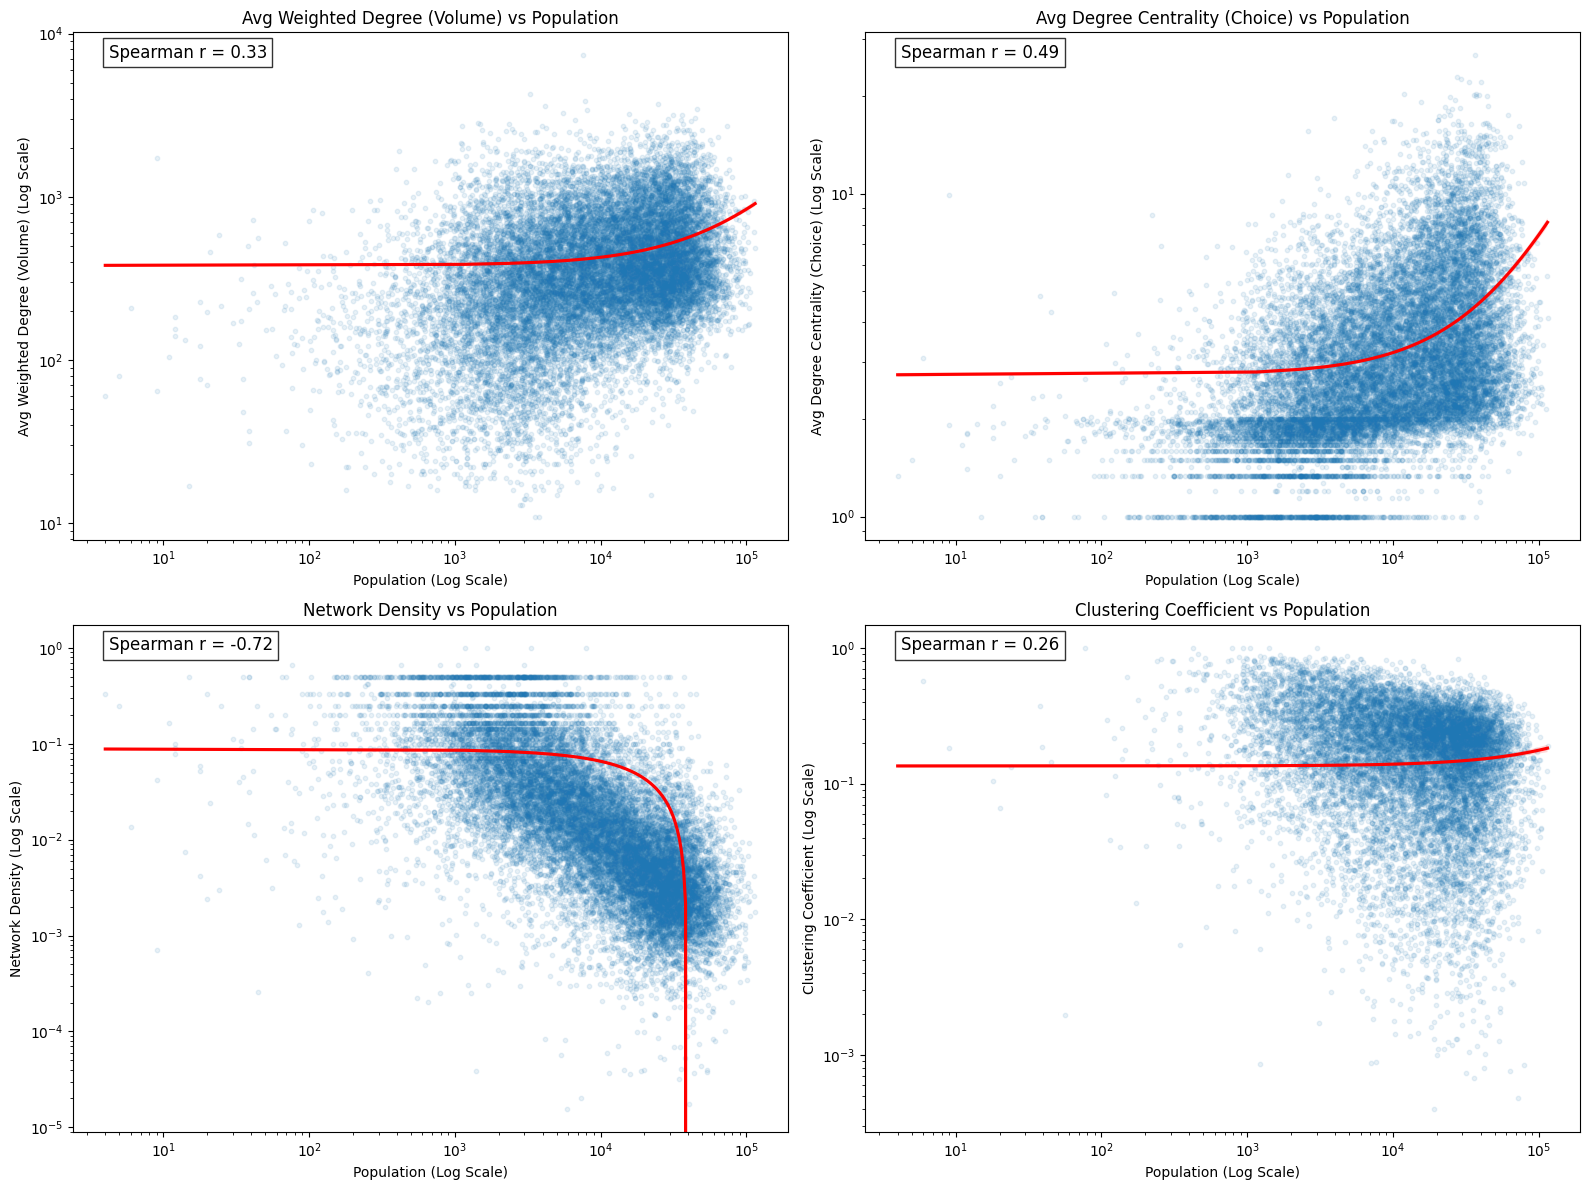

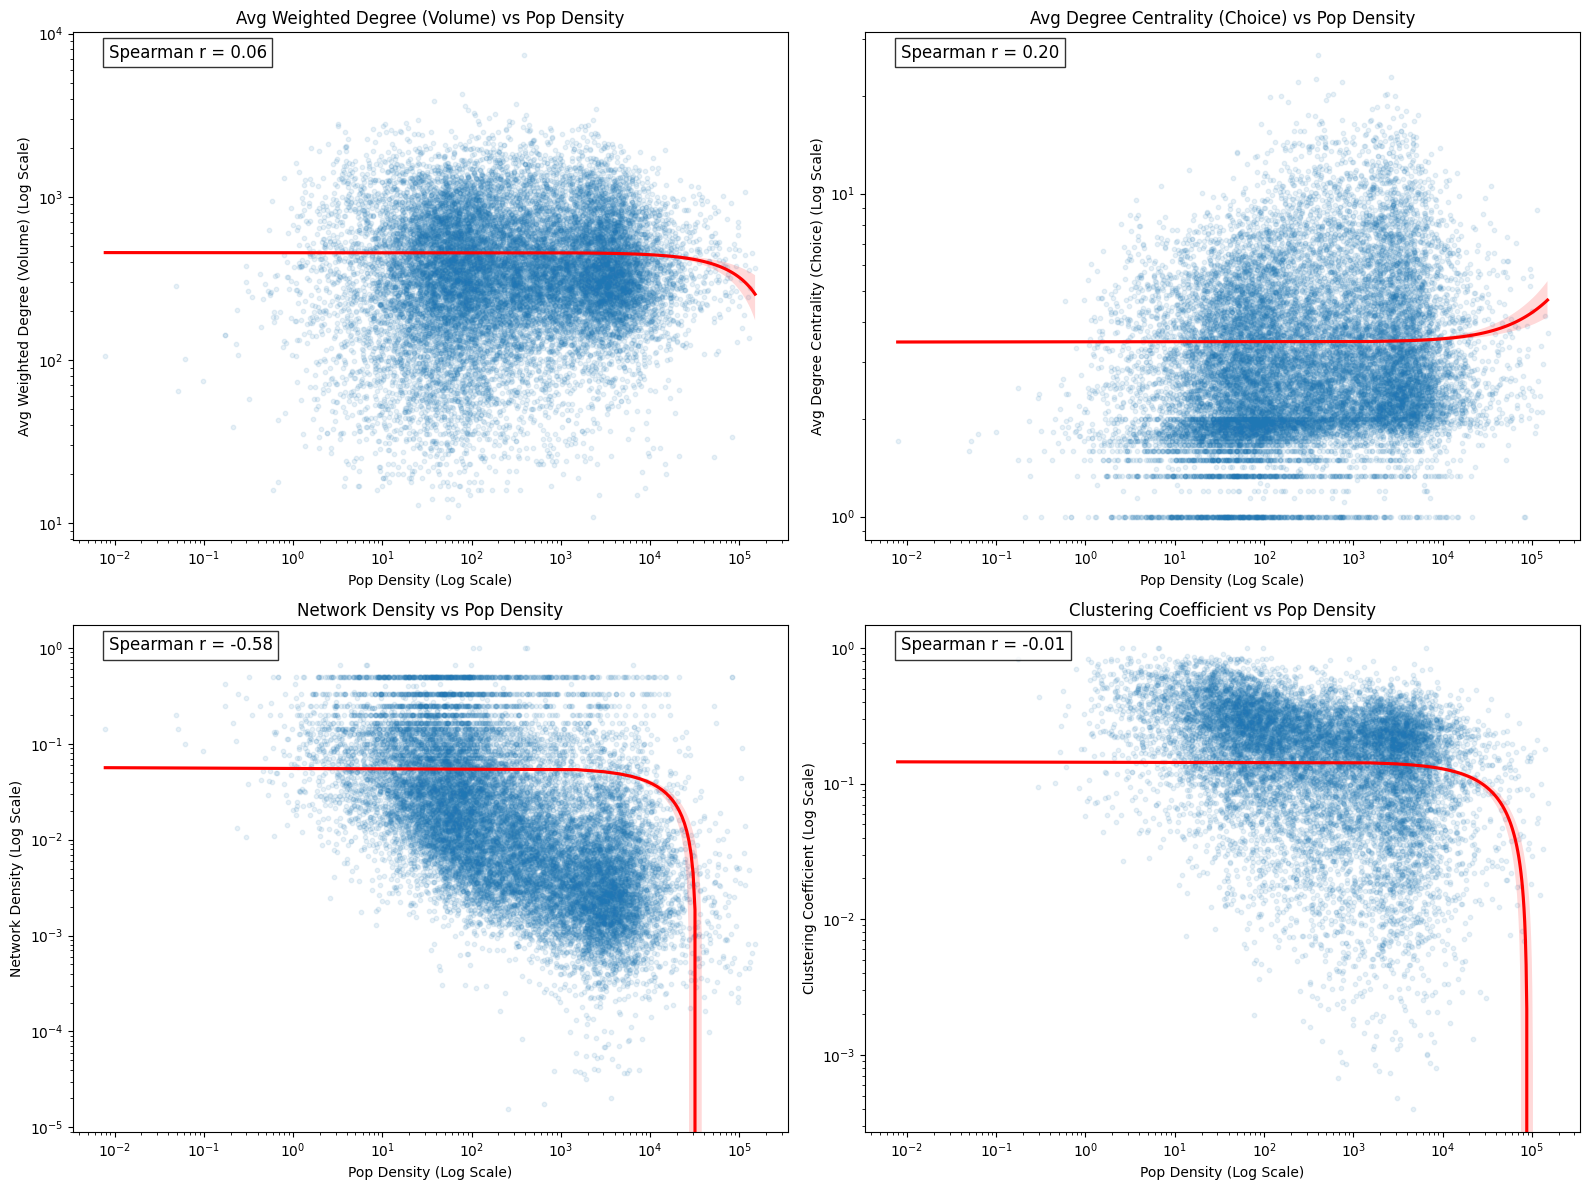

In [16]:
# Plot network correlations

def plot_network_correlations(df, x_col='population', x_label="Population"):
    """
    Plots 4 Key Network Metrics (Volume, Choice, Density, Clustering) against a demographic variable.
    """
    # 1. Setup 2x2 Grid (instead of 1x3)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Flatten the 2D array of axes into a 1D list so we can loop through it easily
    axes_flat = axes.flatten()
    
    # 2. Updated Metrics List (Matching your new CSV headers)
    metrics = [
        ('avg_weighted_degree', 'Avg Weighted Degree (Volume)'),    # The "Intensity"
        ('avg_degree_centrality', 'Avg Degree Centrality (Choice)'), # The "New Metric"
        ('density', 'Network Density'),
        ('clustering_coeff', 'Clustering Coefficient')
    ]
    
    for i, (y_col, y_label) in enumerate(metrics):
        ax = axes_flat[i]
        
        # Check if column exists to avoid crashing if you run this on old data
        if y_col not in df.columns:
            ax.text(0.5, 0.5, f"Column '{y_col}' not found", ha='center')
            continue

        # Plot
        sns.regplot(
            data=df, 
            x=x_col, 
            y=y_col, 
            ax=ax, 
            scatter_kws={'alpha':0.1, 's':10}, 
            line_kws={'color':'red'}
        )
        
        # Log Scales
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        # Labels
        ax.set_title(f"{y_label} vs {x_label}")
        ax.set_xlabel(f"{x_label} (Log Scale)")
        ax.set_ylabel(f"{y_label} (Log Scale)")
        
        # Spearman Correlation
        # We drop NaNs specifically for this pair to ensure correlation works
        clean_data = df[[x_col, y_col]].dropna()
        if len(clean_data) > 0:
            corr = clean_data.corr(method='spearman').iloc[0,1]
            ax.text(0.05, 0.95, f"Spearman r = {corr:.2f}", transform=ax.transAxes, 
                    fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# Run it against Raw Population
plot_network_correlations(final_metrics_merged, x_col='Population', x_label="Population")

# If you calculated density, run it against that too:
plot_network_correlations(final_metrics_merged, x_col='pop_density', x_label="Pop Density")

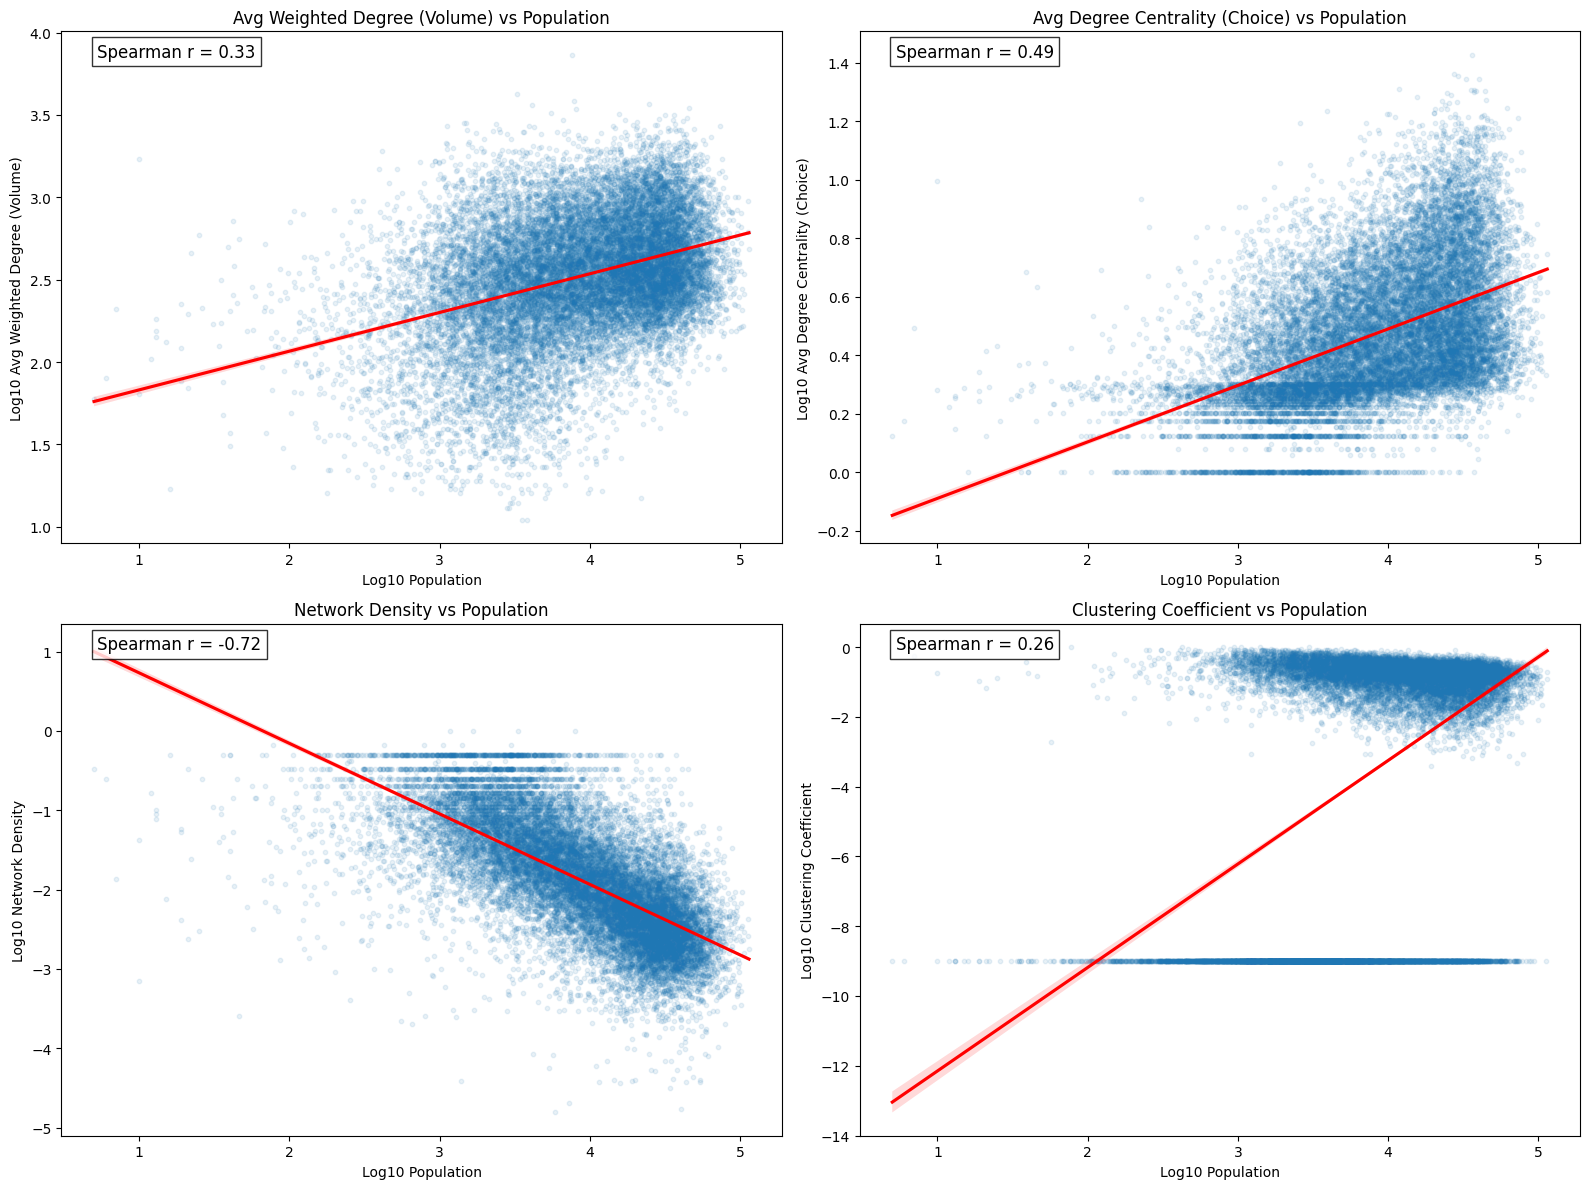

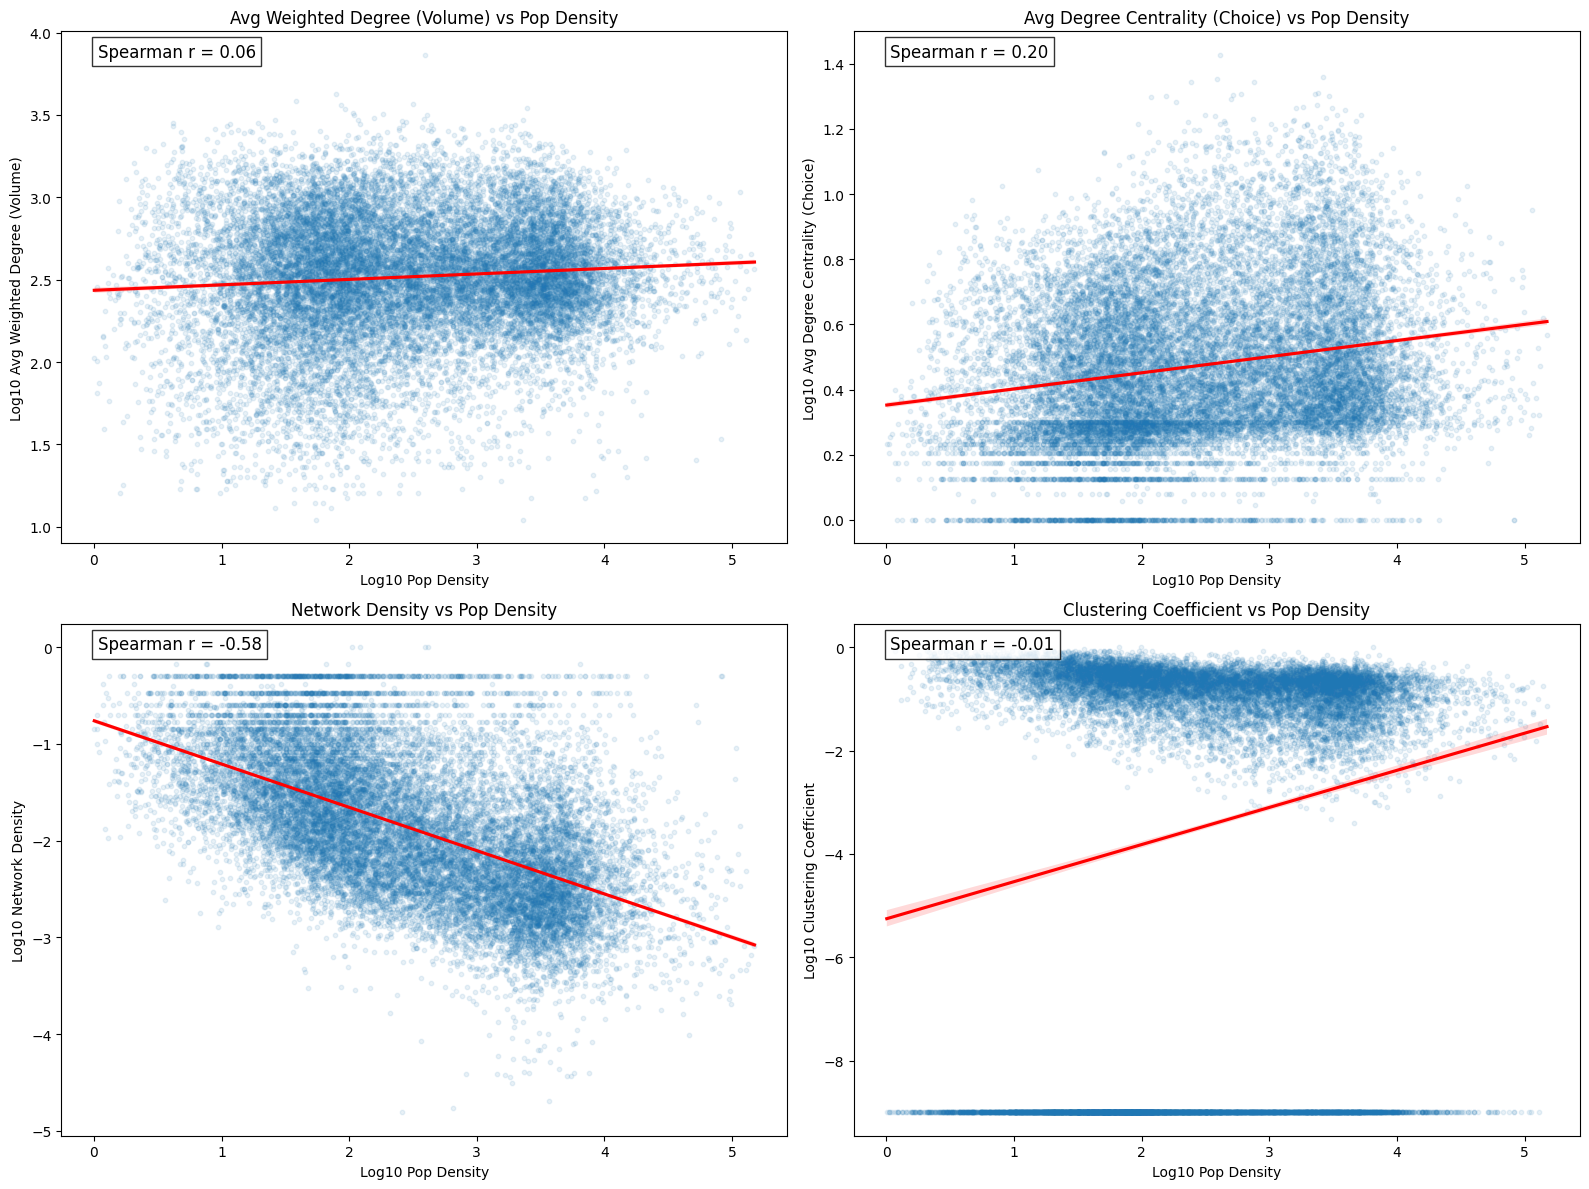

In [19]:
def plot_network_correlations_log_linear(df, x_col='Population', x_label="Population"):
    """
    Plots correlations using Log-Transformed data for the regression line.
    This ensures the red line cuts through the cloud correctly.
    """
    # 1. Setup 2x2 Grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes_flat = axes.flatten()
    
    metrics = [
        ('avg_weighted_degree', 'Avg Weighted Degree (Volume)'),
        ('avg_degree_centrality', 'Avg Degree Centrality (Choice)'),
        ('density', 'Network Density'),
        ('clustering_coeff', 'Clustering Coefficient')
    ]
    
    # 2. Create Temporary Log Columns for Plotting
    # We add 1 to avoid log(0) errors
    plot_df = df.copy()
    plot_df['log_x'] = np.log10(plot_df[x_col] + 1)
    
    for i, (y_col, y_label) in enumerate(metrics):
        ax = axes_flat[i]
        
        if y_col not in df.columns:
            continue

        # Log transform the target metric
        # Use a tiny epsilon (1e-9) to handle true zeros if they exist
        plot_df[f'log_{y_col}'] = np.log10(plot_df[y_col] + 1e-9)

        # 3. Plot using the LOG columns
        sns.regplot(
            data=plot_df, 
            x='log_x', 
            y=f'log_{y_col}', 
            ax=ax, 
            scatter_kws={'alpha':0.1, 's':10}, 
            line_kws={'color':'red'}
        )
        
        # 4. Fix Labels (Since we are plotting logs, the axes are now 1, 2, 3, 4, 5...)
        # We can leave them as 10^1, 10^2 by keeping standard formatting, 
        # OR just label them "Log10(Population)"
        ax.set_title(f"{y_label} vs {x_label}")
        ax.set_xlabel(f"Log10 {x_label}")
        ax.set_ylabel(f"Log10 {y_label}")
        
        # Spearman Correlation (Calculate on raw data, it's rank-based so it doesn't matter)
        clean_data = df[[x_col, y_col]].dropna()
        if len(clean_data) > 0:
            corr = clean_data.corr(method='spearman').iloc[0,1]
            ax.text(0.05, 0.95, f"Spearman r = {corr:.2f}", transform=ax.transAxes, 
                    fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

plot_network_correlations_log_linear(final_metrics_merged, x_col='Population', x_label="Population")
plot_network_correlations_log_linear(final_metrics_merged, x_col='pop_density', x_label="Pop Density")

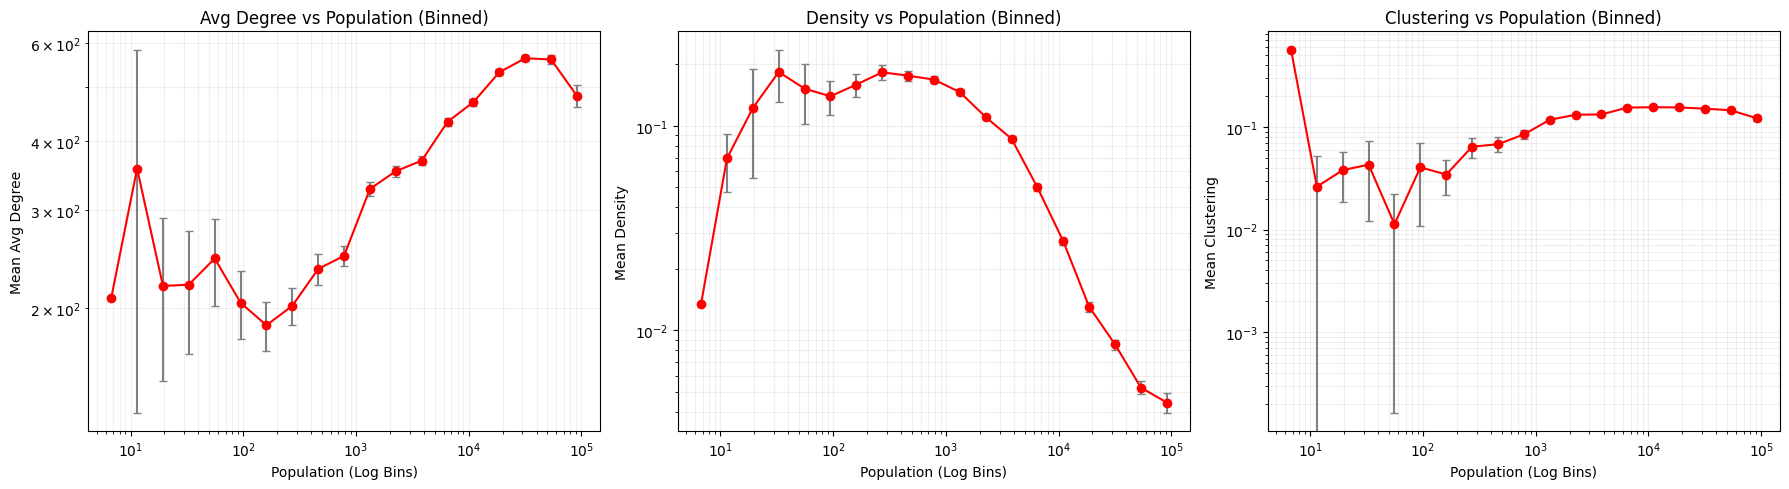

In [25]:
# Binned curves

def plot_binned_trends(df, x_col='Population'):
    """
    Bins the x-axis variable into log-spaced buckets and plots the mean of the y-variables.
    This removes 'cloud' noise and reveals the clean trend line.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['avg_degree', 'density', 'clustering_coeff']
    titles = ['Avg Degree', 'Density', 'Clustering']
    
    # Create Log-Spaced Bins for Population
    # 20 bins from min pop to max pop
    bins = np.logspace(np.log10(df[x_col].min()+1), np.log10(df[x_col].max()), 20)
    
    # Assign each row to a bin
    df['bin'] = pd.cut(df[x_col], bins)
    
    # Group by Bin and calculate Mean + Standard Error
    bin_stats = df.groupby('bin', observed=False)[metrics].agg(['mean', 'sem'])
    
    # Get the center of each bin for plotting
    bin_centers = [i.mid for i in bin_stats.index]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        # Plot the Mean Line
        means = bin_stats[metric]['mean']
        errors = bin_stats[metric]['sem']
        
        ax.errorbar(bin_centers, means, yerr=errors, fmt='-o', color='red', ecolor='gray', capsize=3)
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f"{titles[i]} vs Population (Binned)")
        ax.set_xlabel("Population (Log Bins)")
        ax.set_ylabel(f"Mean {titles[i]}")
        ax.grid(True, which="both", ls="-", alpha=0.2)

    plt.tight_layout()
    plt.show()

# Run this on your data
plot_binned_trends(final_metrics_merged, x_col='Population')

In [6]:
def run_comparative_regression_fixed(df):
    print("--- MULTIVARIABLE REGRESSION ANALYSIS (FIXED) ---")
    print("Model: log(Metric) ~ log(Population) + log(Pop_Density)\n")

    reg_df = df.copy()
    
    # 1. FIX: Rename the predictor to 'log_pop_density' to avoid collision
    reg_df['log_pop'] = np.log10(reg_df['Population'] + 1)
    reg_df['log_pop_density'] = np.log10(reg_df['pop_density'] + 1)
    
    metrics = ['avg_degree', 'density', 'clustering_coeff']
    summary_data = []

    for metric in metrics:
        # Create unique name for the target log column
        target_col = f'log_{metric}'
        reg_df[target_col] = np.log10(reg_df[metric] + 1e-9) 
        
        # 2. FIX: Update formula to use the new predictor name
        formula = f"{target_col} ~ log_pop + log_pop_density"
        
        model = smf.ols(formula=formula, data=reg_df).fit()
        
        summary_data.append({
            'Metric': metric,
            'R-Squared': model.rsquared,
            'Pop Coef': model.params['log_pop'],
            'Pop P-val': model.pvalues['log_pop'],
            'Pop_Density Coef': model.params['log_pop_density'],
            'Pop_Density P-val': model.pvalues['log_pop_density']
        })

    results_df = pd.DataFrame(summary_data)
    pd.options.display.float_format = '{:,.4f}'.format
    print(results_df)
    return results_df

# Run the fixed version
regression_results = run_comparative_regression_fixed(final_metrics_merged)

--- MULTIVARIABLE REGRESSION ANALYSIS (FIXED) ---
Model: log(Metric) ~ log(Population) + log(Pop_Density)

             Metric  R-Squared  Pop Coef  Pop P-val  Pop_Density Coef  \
0        avg_degree     0.1653    0.3356     0.0000           -0.0956   
1           density     0.4858   -0.6993     0.0000           -0.1795   
2  clustering_coeff     0.2078    3.7081     0.0000           -0.7045   

   Pop_Density P-val  
0             0.0000  
1             0.0000  
2             0.0000  


## Step 5: Compute Referral Volume by ZIP Code

Compute total referral volume (incoming and outgoing) for each zip code.

In [ ]:
def compute_zip_referral_volume(G, data_df, output_path=None):
    """
    Compute total referral volume (incoming and outgoing) for each zip code.
    
    Args:
        G: NetworkX graph with referral relationships
        data_df: DataFrame with docgraph_with_zips data
        output_path: Path to save results CSV. Defaults to "data/docgraph-data/zip_referral_volume.csv"
    
    Returns:
        pandas.DataFrame: DataFrame with zip code referral volume statistics
    """
    if output_path is None:
        output_path = os.path.join("data", "docgraph-data", "zip_referral_volume.csv")
    
    print("Using provided DataFrame...")
    # Use provided DataFrame
    df = data_df.copy()
    
    # Convert numeric columns if needed
    numeric_cols = ["Pair_Count", "Unique_Beneficiaries", "Same_Day_Count"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    
    # Create NPI to zip code mapping
    print("Creating NPI to zip code mapping...")
    npi_to_zip = {}
    
    # Map from NPI_1
    for _, row in df.iterrows():
        npi1 = str(row["NPI_1"]).strip()
        zip1 = row.get("NPI_1_Zip")
        if pd.notna(zip1) and str(zip1).strip():
            npi_to_zip[npi1] = str(zip1).strip()
    
    # Map from NPI_2
    for _, row in df.iterrows():
        npi2 = str(row["NPI_2"]).strip()
        zip2 = row.get("NPI_2_Zip")
        if pd.notna(zip2) and str(zip2).strip():
            npi_to_zip[npi2] = str(zip2).strip()
    
    print(f"Mapped {len(npi_to_zip):,} NPIs to zip codes")
    
    # Initialize dictionaries to track volumes
    outgoing_volume = {}  # zip -> total volume of referrals FROM this zip
    incoming_volume = {}  # zip -> total volume of referrals TO this zip
    
    print("Computing referral volumes by zip code...")
    
    # Iterate through all edges in the graph
    for source, target, data in tqdm(G.edges(data=True), desc="Processing edges", total=G.number_of_edges()):
        weight = data.get('weight', 0)
        
        source_zip = npi_to_zip.get(str(source).strip())
        target_zip = npi_to_zip.get(str(target).strip())
        
        # Outgoing volume: source zip sends referrals
        if source_zip:
            outgoing_volume[source_zip] = outgoing_volume.get(source_zip, 0) + weight
        
        # Incoming volume: target zip receives referrals
        if target_zip:
            incoming_volume[target_zip] = incoming_volume.get(target_zip, 0) + weight
    
    # Get all unique zip codes
    all_zips = set(outgoing_volume.keys()) | set(incoming_volume.keys())
    
    # Create results DataFrame
    results = []
    for zip_code in sorted(all_zips):
        results.append({
            'Zip_Code': zip_code,
            'Outgoing_Volume': outgoing_volume.get(zip_code, 0),
            'Incoming_Volume': incoming_volume.get(zip_code, 0),
            'Total_Volume': outgoing_volume.get(zip_code, 0) + incoming_volume.get(zip_code, 0),
            'Net_Volume': incoming_volume.get(zip_code, 0) - outgoing_volume.get(zip_code, 0)  # Positive = net receiver
        })
    
    zip_volume_df = pd.DataFrame(results)
    zip_volume_df = zip_volume_df.sort_values('Total_Volume', ascending=False)
    
    # Save results
    zip_volume_df.to_csv(output_path, index=False)
    print(f"\n✅ Results saved to {output_path}")
    
    # Print summary statistics
    print("\n" + "="*80)
    print("Zip Code Referral Volume Summary")
    print("="*80)
    print(f"Total zip codes: {len(zip_volume_df):,}")
    print(f"\nTop 10 zip codes by total volume:")
    print(zip_volume_df.head(10).to_string(index=False))
    
    print(f"\nStatistics:")
    print(f"  Total outgoing volume: {zip_volume_df['Outgoing_Volume'].sum():,}")
    print(f"  Total incoming volume: {zip_volume_df['Incoming_Volume'].sum():,}")
    print(f"  Average outgoing volume per zip: {zip_volume_df['Outgoing_Volume'].mean():.2f}")
    print(f"  Average incoming volume per zip: {zip_volume_df['Incoming_Volume'].mean():.2f}")
    
    # Net receivers (positive net volume) vs net senders (negative net volume)
    net_receivers = zip_volume_df[zip_volume_df['Net_Volume'] > 0]
    net_senders = zip_volume_df[zip_volume_df['Net_Volume'] < 0]
    balanced = zip_volume_df[zip_volume_df['Net_Volume'] == 0]
    
    print(f"\n  Net receivers (receive more than send): {len(net_receivers):,}")
    print(f"  Net senders (send more than receive): {len(net_senders):,}")
    print(f"  Balanced (equal send/receive): {len(balanced):,}")
    
    return zip_volume_df

# Run Step 5
print("\n" + "="*80)
print("Step 5: Computing Referral Volume by Zip Code")
print("="*80)
zip_volume_df = compute_zip_referral_volume(G, docgraph_with_zips)

## Step 6: Visualize Network Subgraph

Visualize a small subset of the graph.

In [ ]:
def visualize_subgraph(G, max_nodes=50, output_path=None):
    """
    Visualize a small subset of the graph.
    
    Args:
        G: NetworkX graph to visualize
        max_nodes: Maximum number of nodes to include in the visualization
        output_path: Path to save the visualization image
    """
    if output_path is None:
        output_path = os.path.join("data", "docgraph-data", "graph_subset_visualization.png")
    
    print(f"Creating subgraph with up to {max_nodes} nodes...")
    
    # Find a node with high out-degree to start from (a physician who refers to many others)
    if G.is_directed():
        # Get node with highest out-degree
        out_degrees = dict(G.out_degree())
        start_node = max(out_degrees, key=out_degrees.get)
        print(f"Starting from node {start_node} (out-degree: {out_degrees[start_node]})")
        
        # Create subgraph using BFS from start node
        nodes_to_include = {start_node}
        queue = [start_node]
        
        while queue and len(nodes_to_include) < max_nodes:
            current = queue.pop(0)
            # Add neighbors (outgoing edges)
            for neighbor in G.successors(current):
                if neighbor not in nodes_to_include and len(nodes_to_include) < max_nodes:
                    nodes_to_include.add(neighbor)
                    queue.append(neighbor)
                if len(nodes_to_include) >= max_nodes:
                    break
        
        # Create subgraph
        subgraph = G.subgraph(nodes_to_include).copy()
    else:
        # For undirected graphs, just take first max_nodes nodes
        nodes_to_include = list(G.nodes())[:max_nodes]
        subgraph = G.subgraph(nodes_to_include).copy()
    
    print(f"Subgraph created: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")
    
    # Create visualization
    plt.figure(figsize=(24, 20))
    
    # Use spring layout with very high k for maximum spacing
    # k parameter: ideal distance between nodes (higher = more spacing)
    print("Computing layout with maximum spacing...")
    k_value = max(8.0, (50.0 / (subgraph.number_of_nodes() ** 0.5)))
    pos = nx.spring_layout(
        subgraph, 
        k=k_value,  # Very high k for maximum spacing
        iterations=1000,  # Many iterations for best convergence
        seed=42,
        pos=None
    )
    
    # Apply aggressive scaling to spread nodes out much more
    pos_array = np.array(list(pos.values()))
    if len(pos_array) > 0:
        # Scale positions to use much more of the available space
        scale_factor = 2.5  # Increased from 1.5 to 2.5
        center = pos_array.mean(axis=0)
        pos = {node: ((pos[node][0] - center[0]) * scale_factor + center[0], 
                      (pos[node][1] - center[1]) * scale_factor + center[1]) 
               for node in pos.keys()}
    
    # Get edge weights for visualization
    edges = subgraph.edges()
    weights = [subgraph[u][v].get('weight', 1) for u, v in edges]
    
    # Normalize weights for edge width (min width 0.5, max width 5)
    if weights:
        min_weight = min(weights)
        max_weight = max(weights)
        if max_weight > min_weight:
            edge_widths = [0.5 + 4.5 * (w - min_weight) / (max_weight - min_weight) for w in weights]
        else:
            edge_widths = [2.0] * len(weights)
    else:
        edge_widths = [1.0] * len(edges)
    
    # Draw edges
    if subgraph.is_directed():
        # Use FancyArrowPatches for directed graphs to show arrows properly
        nx.draw_networkx_edges(
            subgraph, pos,
            width=edge_widths,
            alpha=0.6,
            edge_color='gray',
            arrows=True,
            arrowsize=20,
            arrowstyle='->',
            connectionstyle='arc3,rad=0.1',
            min_source_margin=15,
            min_target_margin=15
        )
    else:
        # For undirected graphs, use simple edges
        nx.draw_networkx_edges(
            subgraph, pos,
            width=edge_widths,
            alpha=0.6,
            edge_color='gray'
        )
    
    # Draw nodes
    node_sizes = [300 + 100 * subgraph.degree(n) for n in subgraph.nodes()]
    nx.draw_networkx_nodes(
        subgraph, pos,
        node_size=node_sizes,
        node_color='lightblue',
        alpha=0.9,
        edgecolors='black',
        linewidths=1
    )
    
    # Draw labels (full NPI numbers)
    labels = {n: str(n) for n in subgraph.nodes()}
    nx.draw_networkx_labels(
        subgraph, pos,
        labels=labels,
        font_size=8,
        font_weight='bold'
    )
    
    plt.title(f"Referral Network Subgraph\n({subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges)", 
              fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    
    # Save the figure
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"✅ Visualization saved to {output_path}")
    
    plt.show()

# Run Step 6
print("\n" + "="*80)
print("Step 6: Visualizing Small Subset of Graph")
print("="*80)
visualize_subgraph(G, max_nodes=30)

## Pipeline Complete!

All steps have been executed successfully. The outputs include:
- `docgraph_combined.csv` - Combined DocGraph data
- `npi_zip_codes.csv` - NPI to ZIP code mapping
- `docgraph_with_zips.csv` - ZIP-enriched referral data
- `referral_network_directed.graphml` - NetworkX graph file
- `zip_referral_volume.csv` - Referral volume by ZIP code
- `graph_subset_visualization.png` - Network visualization